# Exp 7: Embedding Classifiers Comparison — LR vs XGBoost vs MLP

**Goal:** Compare classical, ensemble, and neural classifiers on the best backbone pair.

**Input to all three:** Raw stacked embeddings `np.hstack([Xi, Xt])` — same input, fair comparison. Each classifier finds its own optimal boundary from the same feature space. The MLP learns a projection internally; LR and XGBoost do not need one.

**Tuning:** Optuna (TPE + MedianPruner) for all three inline.

**Requires:** `results/exp6.json` — run Exp 6 first.

**Install if needed:** `pip install joblib optuna xgboost`

In [2]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import matplotlib.pyplot as plt
import json, os, copy
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT   = Path('../').resolve()
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {DEVICE}  |  Root: {ROOT}')

/Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020/hateful-memes-venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps  |  Root: /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020


## 1. Load Best Backbones from Exp 6

In [3]:
assert (ROOT / 'results/exp6.json').exists(), 'Run exp6 first!'
exp6 = json.load(open(ROOT / 'results/exp6.json'))

BEST_IMG_KEY = exp6['image_backbone']
IMG_DIM      = exp6['img_dim']
BEST_TEXT    = exp6['text_backbone']
TEXT_DIM     = exp6['text_dim']
INPUT_DIM    = IMG_DIM + TEXT_DIM  # raw stacked dim

print(f'Best image key : {BEST_IMG_KEY} (dim={IMG_DIM})')
print(f'Best text      : {BEST_TEXT} (dim={TEXT_DIM})')
print(f'Stacked dim    : {INPUT_DIM}')

Best image key : vit_yolo (dim=768)
Best text      : roberta (dim=768)
Stacked dim    : 1536


## 2. Load & Stack Embeddings

In [4]:
IMG_DIR  = ROOT / 'artifacts/embeddings/image'
TEXT_DIR = ROOT / 'artifacts/embeddings/text'

Xi_tr = np.load(IMG_DIR  / f'train_{BEST_IMG_KEY}.npy').astype(np.float32)
Xt_tr = np.load(TEXT_DIR / f'train_{BEST_TEXT}.npy').astype(np.float32)
y_tr  = np.load(IMG_DIR  / 'train_labels.npy')
Xi_dv = np.load(IMG_DIR  / f'dev_{BEST_IMG_KEY}.npy').astype(np.float32)
Xt_dv = np.load(TEXT_DIR / f'dev_{BEST_TEXT}.npy').astype(np.float32)
y_dv  = np.load(IMG_DIR  / 'dev_labels.npy')

# Normalize each modality separately before stacking
sci = StandardScaler().fit(Xi_tr)
sct = StandardScaler().fit(Xt_tr)
Xi_tr, Xi_dv = sci.transform(Xi_tr), sci.transform(Xi_dv)
Xt_tr, Xt_dv = sct.transform(Xt_tr), sct.transform(Xt_dv)

# Stack — used by LR and XGBoost directly
X_tr_stack = np.hstack([Xi_tr, Xt_tr])
X_dv_stack = np.hstack([Xi_dv, Xt_dv])

n_pos = (y_tr == 1).sum()
n_neg = (y_tr == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
scale_pos_weight = n_neg / n_pos  # for XGBoost

print(f'Stacked train: {X_tr_stack.shape}, dev: {X_dv_stack.shape}')
print(f'pos_weight: {pos_weight.item():.3f}')

Stacked train: (8500, 1536), dev: (500, 1536)
pos_weight: 1.787


## 3. DataLoaders (MLP only)

In [5]:
BATCH_SIZE = 64

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_tr_stack, y_tr, shuffle=True)
dev_loader   = make_loader(X_dv_stack, y_dv)
print(f'MLP batches — Train: {len(train_loader)}, Dev: {len(dev_loader)}')

MLP batches — Train: 133, Dev: 8


## 4. Shared Utilities

In [6]:
os.makedirs(ROOT / 'results/tuning', exist_ok=True)

def save_best_params(exp_name, params, best_auc):
    path = ROOT / f'results/tuning/{exp_name}_best_params.json'
    out  = {'experiment': exp_name, 'best_dev_auc': round(best_auc, 4), 'params': params}
    with open(path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f'Saved → {path}')
    return out


def eval_sklearn(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    return roc_auc_score(y, probs), accuracy_score(y, preds), probs, preds


print('Utilities ready.')

Utilities ready.


## 5. Tune & Fit — Logistic Regression

**Search space:**
- `C`: 1e-3 – 1e2 (log) — inverse regularization strength
- `penalty`: l1, l2
- `solver`: saga (supports both l1/l2 on large data)

LR is fast so 50 trials is feasible.

In [7]:
def lr_objective(trial):
    C       = trial.suggest_float('C', 1e-3, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    model = LogisticRegression(
        C=C, penalty=penalty, solver='saga',
        class_weight='balanced', max_iter=1000, random_state=42
    )
    model.fit(X_tr_stack, y_tr)
    auc, _, _, _ = eval_sklearn(model, X_dv_stack, y_dv)
    return auc


print('Tuning Logistic Regression (50 trials)...')
study_lr = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
    # No pruner for sklearn — trials are fast, pruning not applicable
)
study_lr.optimize(lr_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest AUC (LR): {study_lr.best_value:.4f}')
print(f'Best params  : {study_lr.best_params}')
save_best_params('exp7_lr', study_lr.best_params, study_lr.best_value)

Tuning Logistic Regression (50 trials)...


Best trial: 17. Best value: 0.609424: 100%|██████████| 50/50 [27:15<00:00, 32.71s/it]


Best AUC (LR): 0.6094
Best params  : {'C': 0.11572628051054855, 'penalty': 'l1'}
Saved → /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020/results/tuning/exp7_lr_best_params.json


{'experiment': 'exp7_lr',
 'best_dev_auc': 0.6094,
 'params': {'C': 0.11572628051054855, 'penalty': 'l1'}}

In [8]:
# Refit LR with best params on full train set
p_lr = study_lr.best_params
best_lr = LogisticRegression(
    C=p_lr['C'], penalty=p_lr['penalty'], solver='saga',
    class_weight='balanced', max_iter=1000, random_state=42
)
best_lr.fit(X_tr_stack, y_tr)
lr_auc, lr_acc, lr_probs, lr_preds = eval_sklearn(best_lr, X_dv_stack, y_dv)
print(f'LR final Dev AUC: {lr_auc:.4f}  Acc: {lr_acc:.4f}')

LR final Dev AUC: 0.6094  Acc: 0.5520


## 6. Tune & Fit — XGBoost

**Search space:**
- `n_estimators`: 100 – 500
- `max_depth`: 3 – 8
- `learning_rate`: 1e-3 – 0.3 (log)
- `subsample`: 0.6 – 1.0
- `colsample_bytree`: 0.6 – 1.0
- `min_child_weight`: 1 – 10

`scale_pos_weight` fixed to `n_neg/n_pos` to handle class imbalance.

In [10]:
def xgb_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 100, 500),
        'max_depth':          trial.suggest_int('max_depth', 3, 8),
        'learning_rate':      trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight':   scale_pos_weight,
        'eval_metric':        'auc',
        'early_stopping_rounds': 20,   # moved here
        'random_state':       42,
        'n_jobs':             -1
    }
    model = XGBClassifier(**params)
    model.fit(X_tr_stack, y_tr,
              eval_set=[(X_dv_stack, y_dv)],
              verbose=False)
    auc, _, _, _ = eval_sklearn(model, X_dv_stack, y_dv)
    return auc


print('Tuning XGBoost (30 trials)...')
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest AUC (XGB): {study_xgb.best_value:.4f}')
print(f'Best params   : {study_xgb.best_params}')
save_best_params('exp7_xgb', study_xgb.best_params, study_xgb.best_value)

Tuning XGBoost (30 trials)...


Best trial: 18. Best value: 0.623872: 100%|██████████| 30/30 [01:50<00:00,  3.68s/it]


Best AUC (XGB): 0.6239
Best params   : {'n_estimators': 172, 'max_depth': 6, 'learning_rate': 0.11799352585860486, 'subsample': 0.9925964817668709, 'colsample_bytree': 0.9585165151166396, 'min_child_weight': 9}
Saved → /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020/results/tuning/exp7_xgb_best_params.json


{'experiment': 'exp7_xgb',
 'best_dev_auc': 0.6239,
 'params': {'n_estimators': 172,
  'max_depth': 6,
  'learning_rate': 0.11799352585860486,
  'subsample': 0.9925964817668709,
  'colsample_bytree': 0.9585165151166396,
  'min_child_weight': 9}}

In [11]:
# Refit XGBoost with best params
p_xgb = study_xgb.best_params
best_xgb = XGBClassifier(
    n_estimators=p_xgb['n_estimators'],
    max_depth=p_xgb['max_depth'],
    learning_rate=p_xgb['learning_rate'],
    subsample=p_xgb['subsample'],
    colsample_bytree=p_xgb['colsample_bytree'],
    min_child_weight=p_xgb['min_child_weight'],
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,   # moved here
    random_state=42,
    n_jobs=-1
)
best_xgb.fit(X_tr_stack, y_tr,
             eval_set=[(X_dv_stack, y_dv)],
             verbose=False)
xgb_auc, xgb_acc, xgb_probs, xgb_preds = eval_sklearn(best_xgb, X_dv_stack, y_dv)
print(f'XGBoost final Dev AUC: {xgb_auc:.4f}  Acc: {xgb_acc:.4f}')

XGBoost final Dev AUC: 0.6239  Acc: 0.5880


## 7. Tune & Train — MLP

**Search space:**
- `hidden1`: 256, 512, 1024
- `hidden2`: 64, 128, 256
- `hidden3`: 16, 32, 64 (optional deeper layer)
- `dropout1/2`: 0.2 – 0.5
- `lr`: 1e-4 – 5e-3 (log)
- `weight_decay`: 1e-5 – 1e-2 (log)

MLP takes raw stacked input — learns its own projection internally via hidden layers.

In [12]:
class StackedMLP(nn.Module):
    def __init__(self, input_dim, h1=512, h2=128, h3=32, d1=0.4, d2=0.3, d3=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),        nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, h3),        nn.LayerNorm(h3), nn.GELU(), nn.Dropout(d3),
            nn.Linear(h3, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)


def run_epoch_mlp(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


def quick_train_mlp(model, criterion, lr, weight_decay, epochs=40, patience=8, trial=None):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_auc, best_state, patience_ctr = 0.0, None, 0
    for epoch in range(1, epochs + 1):
        run_epoch_mlp(train_loader, model, criterion, optimizer)
        _, dv_auc, _, _, _ = run_epoch_mlp(dev_loader, model, criterion)
        scheduler.step()
        if dv_auc > best_auc:
            best_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
        if trial is not None:
            trial.report(dv_auc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        if patience_ctr >= patience:
            break
    model.load_state_dict(best_state)
    return model, best_auc


criterion_mlp = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def mlp_objective(trial):
    h1 = trial.suggest_categorical('hidden1', [256, 512, 1024])
    h2 = trial.suggest_categorical('hidden2', [64, 128, 256])
    h3 = trial.suggest_categorical('hidden3', [16, 32, 64])
    d1 = trial.suggest_float('dropout1', 0.2, 0.5)
    d2 = trial.suggest_float('dropout2', 0.2, 0.5)
    d3 = trial.suggest_float('dropout3', 0.1, 0.4)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

    if h2 >= h1 or h3 >= h2:
        raise optuna.exceptions.TrialPruned()

    model = StackedMLP(INPUT_DIM, h1=h1, h2=h2, h3=h3, d1=d1, d2=d2, d3=d3).to(DEVICE)
    _, best_auc = quick_train_mlp(model, criterion_mlp, lr, wd, trial=trial)
    return best_auc


print('Tuning MLP (30 trials)...')
study_mlp = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study_mlp.optimize(mlp_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest AUC (MLP): {study_mlp.best_value:.4f}')
print(f'Best params   : {study_mlp.best_params}')
save_best_params('exp7_mlp', study_mlp.best_params, study_mlp.best_value)

Tuning MLP (30 trials)...


Best trial: 0. Best value: 0.681984: 100%|██████████| 30/30 [03:58<00:00,  7.94s/it]


Best AUC (MLP): 0.6820
Best params   : {'hidden1': 512, 'hidden2': 64, 'hidden3': 32, 'dropout1': 0.41242177333881364, 'dropout2': 0.20617534828874073, 'dropout3': 0.39097295564859835, 'lr': 0.002595942550311264, 'weight_decay': 4.335281794951564e-05}
Saved → /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020/results/tuning/exp7_mlp_best_params.json


{'experiment': 'exp7_mlp',
 'best_dev_auc': 0.682,
 'params': {'hidden1': 512,
  'hidden2': 64,
  'hidden3': 32,
  'dropout1': 0.41242177333881364,
  'dropout2': 0.20617534828874073,
  'dropout3': 0.39097295564859835,
  'lr': 0.002595942550311264,
  'weight_decay': 4.335281794951564e-05}}

## 8. Retrain MLP with Best Params

In [13]:
p_mlp = study_mlp.best_params
best_model_mlp = StackedMLP(
    INPUT_DIM,
    h1=p_mlp['hidden1'], h2=p_mlp['hidden2'], h3=p_mlp['hidden3'],
    d1=p_mlp['dropout1'], d2=p_mlp['dropout2'], d3=p_mlp['dropout3']
).to(DEVICE)

optimizer = optim.AdamW(best_model_mlp.parameters(),
                         lr=p_mlp['lr'], weight_decay=p_mlp['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

history_mlp = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
best_auc_mlp, best_state_mlp, patience_ctr = 0.0, None, 0
PATIENCE = 10

print('Retraining MLP with best params...')
for epoch in range(1, 51):
    tr_loss, tr_auc, tr_acc, _, _ = run_epoch_mlp(train_loader, best_model_mlp, criterion_mlp, optimizer)
    dv_loss, dv_auc, dv_acc, _, _ = run_epoch_mlp(dev_loader,   best_model_mlp, criterion_mlp)
    scheduler.step()
    history_mlp['train_loss'].append(tr_loss); history_mlp['dev_loss'].append(dv_loss)
    history_mlp['train_auc'].append(tr_auc);   history_mlp['dev_auc'].append(dv_auc)

    if dv_auc > best_auc_mlp:
        best_auc_mlp = dv_auc; best_state_mlp = copy.deepcopy(best_model_mlp.state_dict())
        patience_ctr = 0; flag = '  <- best'
    else:
        patience_ctr += 1; flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} | '
          f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

best_model_mlp.load_state_dict(best_state_mlp)
_, mlp_auc, mlp_acc, mlp_probs, mlp_true = run_epoch_mlp(dev_loader, best_model_mlp, criterion_mlp)
mlp_preds = (mlp_probs >= 0.5).astype(int)
print(f'\nMLP final Dev AUC: {mlp_auc:.4f}  Acc: {mlp_acc:.4f}')

Retraining MLP with best params...
Ep 01 | Tr Loss 0.8225 AUC 0.6820 | Dev Loss 1.0313 AUC 0.6233 Acc 0.5760  <- best
Ep 02 | Tr Loss 0.7387 AUC 0.7699 | Dev Loss 1.0914 AUC 0.6215 Acc 0.5740  (patience 1/10)
Ep 03 | Tr Loss 0.6785 AUC 0.8146 | Dev Loss 1.1204 AUC 0.6466 Acc 0.6020  <- best
Ep 04 | Tr Loss 0.6175 AUC 0.8515 | Dev Loss 1.2132 AUC 0.6422 Acc 0.5860  (patience 1/10)
Ep 05 | Tr Loss 0.5721 AUC 0.8741 | Dev Loss 1.1621 AUC 0.6479 Acc 0.5980  <- best
Ep 06 | Tr Loss 0.5263 AUC 0.8950 | Dev Loss 1.3044 AUC 0.6476 Acc 0.5920  (patience 1/10)
Ep 07 | Tr Loss 0.4681 AUC 0.9176 | Dev Loss 1.3322 AUC 0.6516 Acc 0.6040  <- best
Ep 08 | Tr Loss 0.4251 AUC 0.9319 | Dev Loss 1.6138 AUC 0.6342 Acc 0.5900  (patience 1/10)
Ep 09 | Tr Loss 0.3780 AUC 0.9461 | Dev Loss 1.7172 AUC 0.6298 Acc 0.6080  (patience 2/10)
Ep 10 | Tr Loss 0.3579 AUC 0.9517 | Dev Loss 1.5810 AUC 0.6505 Acc 0.6120  (patience 3/10)
Ep 11 | Tr Loss 0.3116 AUC 0.9631 | Dev Loss 1.9983 AUC 0.6465 Acc 0.6080  (patience 4/

## 9. MLP Training Curves

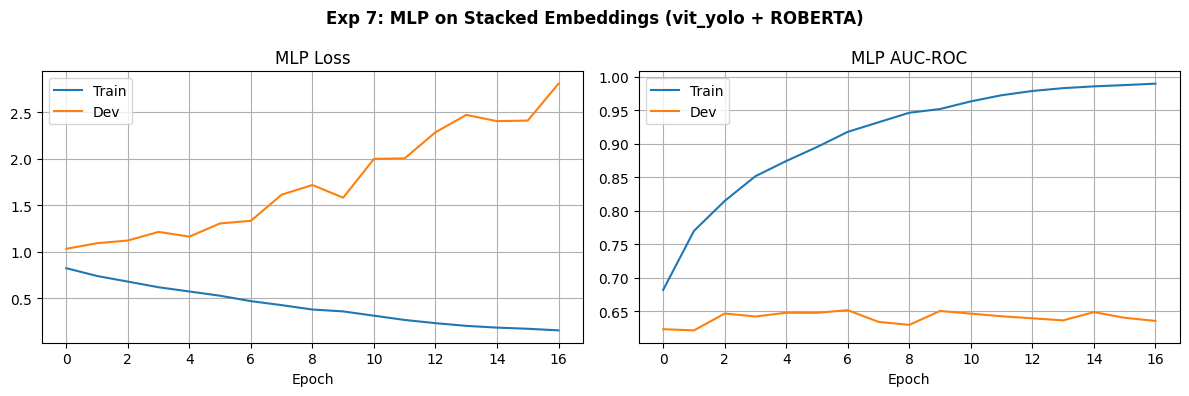

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_mlp['train_loss'], label='Train')
axes[0].plot(history_mlp['dev_loss'],   label='Dev')
axes[0].set_title('MLP Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_mlp['train_auc'], label='Train')
axes[1].plot(history_mlp['dev_auc'],   label='Dev')
axes[1].set_title('MLP AUC-ROC'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)
plt.suptitle(f'Exp 7: MLP on Stacked Embeddings ({BEST_IMG_KEY} + {BEST_TEXT.upper()})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/07_mlp_training_curves.png', dpi=150)
plt.show()

## 10. Results Summary & Classifier Selection

In [15]:
results = {
    'lr':  {'dev_auc_roc': round(float(lr_auc),  4), 'dev_accuracy': round(float(lr_acc),  4)},
    'xgb': {'dev_auc_roc': round(float(xgb_auc), 4), 'dev_accuracy': round(float(xgb_acc), 4)},
    'mlp': {'dev_auc_roc': round(float(mlp_auc), 4), 'dev_accuracy': round(float(mlp_acc), 4)}
}

print('=' * 60)
print(f'EXP 7 — Classifier Comparison | {BEST_IMG_KEY} + {BEST_TEXT.upper()} | Dev Set')
print('=' * 60)
labels = {'lr': 'Logistic Regression', 'xgb': 'XGBoost', 'mlp': 'MLP'}
for clf in ['lr', 'xgb', 'mlp']:
    r = results[clf]
    print(f'  {labels[clf]:25s}: AUC = {r["dev_auc_roc"]:.4f}  Acc = {r["dev_accuracy"]:.4f}')

best_clf = max(results, key=lambda k: results[k]['dev_auc_roc'])
print(f'\n-> Best classifier: {labels[best_clf]} (AUC = {results[best_clf]["dev_auc_roc"]:.4f})')

EXP 7 — Classifier Comparison | vit_yolo + ROBERTA | Dev Set
  Logistic Regression      : AUC = 0.6094  Acc = 0.5520
  XGBoost                  : AUC = 0.6239  Acc = 0.5880
  MLP                      : AUC = 0.6516  Acc = 0.6040

-> Best classifier: MLP (AUC = 0.6516)


## 11. Classification Reports

In [17]:
clfs = {'lr': (lr_probs, lr_preds, y_dv),
        'xgb': (xgb_probs, xgb_preds, y_dv),
        'mlp': (mlp_probs, mlp_preds, mlp_true)}

for clf, (probs, preds, true) in clfs.items():
    print(f'--- {labels[clf]} ---')
    print(classification_report(true, preds, target_names=['Not Hateful', 'Hateful']))

--- Logistic Regression ---
              precision    recall  f1-score   support

 Not Hateful       0.54      0.70      0.61       250
     Hateful       0.57      0.40      0.47       250

    accuracy                           0.55       500
   macro avg       0.56      0.55      0.54       500
weighted avg       0.56      0.55      0.54       500

--- XGBoost ---
              precision    recall  f1-score   support

 Not Hateful       0.56      0.83      0.67       250
     Hateful       0.67      0.35      0.46       250

    accuracy                           0.59       500
   macro avg       0.61      0.59      0.56       500
weighted avg       0.61      0.59      0.56       500

--- MLP ---
              precision    recall  f1-score   support

 Not Hateful       0.58      0.74      0.65       250
     Hateful       0.64      0.47      0.54       250

    accuracy                           0.60       500
   macro avg       0.61      0.60      0.60       500
weighted avg      

## 12. Save Models & Results

In [18]:
os.makedirs(ROOT / 'models', exist_ok=True)
os.makedirs(ROOT / 'outputs', exist_ok=True)

import joblib
joblib.dump(best_lr,  ROOT / f'models/07_{BEST_IMG_KEY}_{BEST_TEXT}_lr.pkl')
joblib.dump(best_xgb, ROOT / f'models/07_{BEST_IMG_KEY}_{BEST_TEXT}_xgb.pkl')
torch.save(best_state_mlp, ROOT / f'models/07_{BEST_IMG_KEY}_{BEST_TEXT}_mlp.pt')

exp7_out = {
    'experiment': '07_EmbeddingClassifierComparison',
    'image_backbone': BEST_IMG_KEY, 'img_dim': IMG_DIM,
    'text_backbone': BEST_TEXT, 'text_dim': TEXT_DIM,
    'input': f'raw stacked embeddings (dim={INPUT_DIM})',
    'results': results,
    'best_classifier': best_clf
}
with open(ROOT / 'results/exp7.json', 'w') as f:
    json.dump(exp7_out, f, indent=2)

print('Saved:')
print(f'  models/07_{BEST_IMG_KEY}_{BEST_TEXT}_lr.pkl')
print(f'  models/07_{BEST_IMG_KEY}_{BEST_TEXT}_xgb.pkl')
print(f'  models/07_{BEST_IMG_KEY}_{BEST_TEXT}_mlp.pt')
print('  results/exp7.json')
print(json.dumps(exp7_out, indent=2))

Saved:
  models/07_vit_yolo_roberta_lr.pkl
  models/07_vit_yolo_roberta_xgb.pkl
  models/07_vit_yolo_roberta_mlp.pt
  results/exp7.json
{
  "experiment": "07_EmbeddingClassifierComparison",
  "image_backbone": "vit_yolo",
  "img_dim": 768,
  "text_backbone": "roberta",
  "text_dim": 768,
  "input": "raw stacked embeddings (dim=1536)",
  "results": {
    "lr": {
      "dev_auc_roc": 0.6094,
      "dev_accuracy": 0.552
    },
    "xgb": {
      "dev_auc_roc": 0.6239,
      "dev_accuracy": 0.588
    },
    "mlp": {
      "dev_auc_roc": 0.6516,
      "dev_accuracy": 0.604
    }
  },
  "best_classifier": "mlp"
}
